## Figure 4 — Artificial Count Inflation by scAR and CellClear

Characterizes the artificial count increments introduced by scAR and CellClear —
counts added to cells beyond their original expression — across both controlled
mixture datasets and real biological tissues. Investigates whether these artificial
counts drive the emergence of spurious cell type annotations.

### Required files (obtained after running respective notebooks in `Processing/`)

**hgmm mixture datasets** (scAR + CellClear, 6 sizes):
- `hgmm{1k,5k,6k,10k,12k,20k}_mixture_scar.h5ad` / `hgmm1k_mixture_scar.h5ad`
- `hgmm{1k,5k,6k,10k,12k,20k}_mixture_cellclear_processed.h5ad`

**Biological datasets** (uncorrected + scAR + CellClear where available):
- `wbc_rhapsody_{uncorrected,scar}_processed.h5ad` *(no CellClear for WBC)*
- `pbmc_chromium_{uncorrected,scar,cellclear}_processed.h5ad`
- `pfc_nucleus_{uncorrected,scar,cellclear}_processed.h5ad`

> All `.h5ad` files must contain `layers['raw']` and `layers['corr']`.
> Biological dataset files additionally require `obs` columns
> `celltypist_cell_label_coarse`, `celltypist_cell_label_fine` (WBC/PBMC)
> or `celltypist_cell_label` (PFC).

### Figures produced
- **Fig_4A.png** — Horizontal bar chart of original, retained, and artificial counts per dataset and tool
- **Fig_4_stripplot_{dataset}_{tool}.png** — Per-cell raw vs corrected expression in emerged cell types (WBC/PBMC/PFC)
- **Fig_4_summary_table.png** — Summary table of emerged cell types, cells affected, and top inflated genes
- **emerged_celltypes_summary.csv** — Machine-readable version of the emerged cell type results

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import re
plt.rcParams['font.family'] = 'Arial'

TOOL_COLORS = {'scar': '#C73E1D', 'cellclear': '#6A4C93'}

# hgmm files (scAR + CellClear)
HGMM_FILES = {
    f'hgmm{k}_{t}': f'figure4_data/hgmm{k}_mixture_{t}{"" if t=="scar" else ""}_processed.h5ad'
    for k in ['1k','5k','6k','10k','12k','20k']
    for t in ['scar','cellclear']
}
# correct the scar naming inconsistency for 1k
HGMM_FILES['hgmm1k_scar'] = 'figure4_data/hgmm1k_mixture_scar.h5ad'

# Biological dataset files
BIO_FILES = {
    'wbc':  {
        'uncorrected': 'figure4_data/wbc_rhapsody_uncorrected_processed.h5ad',
        'scar':        'figure4_data/wbc_rhapsody_scar_processed.h5ad',
        'cellclear':   None,
        'label_cols':  ['celltypist_cell_label_coarse', 'celltypist_cell_label_fine'],
    },
    'pbmc': {
        'uncorrected': 'figure4_data/pbmc_chromium_uncorrected_processed.h5ad',
        'scar':        'figure4_data/pbmc_chromium_scar_processed.h5ad',
        'cellclear':   'figure4_data/pbmc_chromium_cellclear_processed.h5ad',
        'label_cols':  ['celltypist_cell_label_coarse', 'celltypist_cell_label_fine'],
    },
    'pfc':  {
        'uncorrected': 'figure4_data/pfc_nucleus_uncorrected_processed.h5ad',
        'scar':        'figure4_data/pfc_nucleus_scar_processed.h5ad',
        'cellclear':   'figure4_data/pfc_nucleus_cellclear_processed.h5ad',
        'label_cols':  ['celltypist_cell_label'],
    },
}

# Hardcoded stripplot configs per dataset/tool
STRIPPLOT_CONFIG = {
    'wbc': {
        'scar': {
            'layout': 'gridspec',  # top + 2 bottom
            'panels': [
                {'ct': 'Granulocytes',             'label_col': 'celltypist_cell_label_coarse',
                 'genes': ['LTF','LCN2','IFNG','CCL7','CCL2','CXCL9','CCL18','MMP8'],
                 'canonical': ['CCL2','CAMP','CLC','MMP8']},
                {'ct': 'Late erythroid',           'label_col': 'celltypist_cell_label_fine',
                 'genes': ['LTF','IFNG','LCN2','PF4'],
                 'canonical': ['LTF','IFNG','PF4']},
                {'ct': 'Megakaryocytes/platelets', 'label_col': 'celltypist_cell_label_fine',
                 'genes': ['CCL8','CCL2','SERPINB2','C1QB'],
                 'canonical': ['CCL8','CCL2','SERPINB2']},
            ]
        }
    },
    'pbmc': {
        'scar': {
            'layout': 'single',
            'panels': [
                {'ct': 'HSC/MPP', 'label_col': 'celltypist_cell_label_coarse',
                 'genes': ['IGLC3','TRIM47','MKI67','GINS4','DUSP19','PXDN','TOX2'],
                 'canonical': ['CD34','KIT','MLLT3','IGLC3','MKI67']},
            ]
        }
    },
    'pfc': {
        'scar': {
            'layout': '2x2',
            'panels': [
                {'ct': 'L6 FEZF2 DCBLD1 MITF', 'label_col': 'celltypist_cell_label',
                 'genes': ['GRIK1','CDH20','DOCK10'], 'canonical': ['GRIK1','CDH20']},
                {'ct': 'InN SST THSD7B',         'label_col': 'celltypist_cell_label',
                 'genes': ['PLP1','SEMA5A','GPC5'],  'canonical': ['SEMA5A']},
            ]
        },
        'cellclear': {
            'layout': '2x2',
            'panels': [
                {'ct': 'InN PVALB GRIN2C',       'label_col': 'celltypist_cell_label',
                 'genes': ['MALAT1','DPP10','ERBB4'],   'canonical': ['ERBB4']},
                {'ct': 'L6 FEZF2 AMOTL1 CDH6',   'label_col': 'celltypist_cell_label',
                 'genes': ['MALAT1','ROBO2','NRG3'],    'canonical': ['ROBO2','NRG3']},
            ]
        }
    }
}

hgmm1k_scar: removal=18.1%, artificial=17.1%
hgmm1k_cellclear: removal=97.2%, artificial=95.5%
hgmm5k_scar: removal=22.9%, artificial=19.4%
hgmm5k_cellclear: removal=99.1%, artificial=98.7%
hgmm6k_scar: removal=21.8%, artificial=18.3%
hgmm6k_cellclear: removal=99.0%, artificial=98.3%
hgmm10k_scar: removal=23.7%, artificial=21.0%
hgmm10k_cellclear: removal=98.2%, artificial=97.0%
hgmm12k_scar: removal=21.0%, artificial=17.2%
hgmm12k_cellclear: removal=99.0%, artificial=98.4%
hgmm20k_scar: removal=22.9%, artificial=17.5%
hgmm20k_cellclear: removal=97.2%, artificial=95.7%
wbc_scar: removal=72.4%, artificial=59.7%
pbmc_scar: removal=47.3%, artificial=25.8%
pbmc_cellclear: removal=96.3%, artificial=95.3%
pfc_scar: removal=49.9%, artificial=32.5%
pfc_cellclear: removal=95.4%, artificial=93.3%


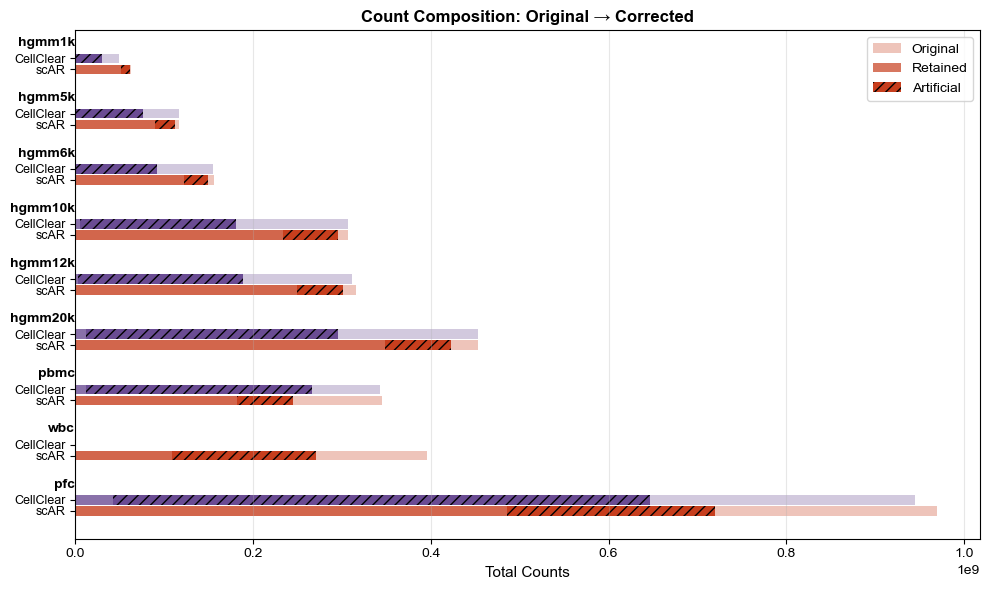

In [2]:
def sort_by_k(name):
    m = re.search(r'(\d+)k', name)
    return int(m.group(1)) if m else 0

# Sequential load — free memory immediately after extracting scalars
results = []
for key, path in HGMM_FILES.items():
    dataset, tool = key.rsplit('_', 1)
    adata = sc.read_h5ad(path)
    diff = adata.layers['corr'] - adata.layers['raw']
    diff_arr = diff.toarray() if hasattr(diff, 'toarray') else np.array(diff)
    raw_total = float(adata.layers['raw'].sum())
    removal   = float(np.abs(diff_arr[diff_arr < 0].sum()))
    increment = float(diff_arr[diff_arr > 0].sum())
    results.append({'dataset': dataset, 'tool': tool, 'n_cells': adata.shape[0],
                    'raw_total': raw_total, 'removal': removal, 'increment': increment,
                    'pct_removal': 100*removal/raw_total,
                    'pct_increment': 100*increment/(raw_total - removal + increment)})
    del adata, diff, diff_arr
    print(f"{key}: removal={results[-1]['pct_removal']:.1f}%, artificial={results[-1]['pct_increment']:.1f}%")

# Also load bio datasets for the bar plot
for dataset_name, config in BIO_FILES.items():
    for tool_key, path in [('scar', config['scar']), ('cellclear', config['cellclear'])]:
        if path is None: continue
        adata = sc.read_h5ad(path)
        diff = adata.layers['corr'] - adata.layers['raw']
        diff_arr = diff.toarray() if hasattr(diff, 'toarray') else np.array(diff)
        raw_total = float(adata.layers['raw'].sum())
        removal   = float(np.abs(diff_arr[diff_arr < 0].sum()))
        increment = float(diff_arr[diff_arr > 0].sum())
        results.append({'dataset': dataset_name, 'tool': tool_key, 'n_cells': adata.shape[0],
                        'raw_total': raw_total, 'removal': removal, 'increment': increment,
                        'pct_removal': 100*removal/raw_total,
                        'pct_increment': 100*increment/(raw_total - removal + increment)})
        del adata, diff, diff_arr
        print(f"{dataset_name}_{tool_key}: removal={results[-1]['pct_removal']:.1f}%, artificial={results[-1]['pct_increment']:.1f}%")

# Plot A — horizontal bar chart
hgmm_ds = sorted(set(r['dataset'] for r in results if 'hgmm' in r['dataset']), key=sort_by_k, reverse=True)
bio_ds   = ['pfc', 'wbc', 'pbmc']
ds_order = bio_ds + hgmm_ds  # bio datasets will simply have no bar if not in results

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(ds_order)) * 2

for idx, dataset in enumerate(ds_order):
    for jdx, (tool, color) in enumerate([('scar','#C73E1D'), ('cellclear','#6A4C93')]):
        d = next((r for r in results if r['dataset']==dataset and r['tool']==tool), None)
        if d is None: continue
        y        = y_pos[idx] + jdx * 0.4
        retained = d['raw_total'] - d['removal']
        ax.barh(y, d['raw_total'], height=0.35, color=color, alpha=0.3,
                label='Original'   if idx==0 and jdx==0 else '')
        ax.barh(y, retained,       height=0.35, color=color, alpha=0.7,
                label='Retained'   if idx==0 and jdx==0 else '')
        ax.barh(y, d['increment'], height=0.35, color=color, alpha=1.0,
                hatch='///', left=retained,
                label='Artificial' if idx==0 and jdx==0 else '')

yticks, yticklabels = [], []
for idx, dataset in enumerate(ds_order):
    yticks.extend([y_pos[idx], y_pos[idx]+0.4])
    yticklabels.extend(['scAR','CellClear'])
    ax.text(0, y_pos[idx]+0.95, dataset, transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(yticks); ax.set_yticklabels(yticklabels, fontsize=9)
ax.set_xlabel('Total Counts', fontsize=11)
ax.set_title('Count Composition: Original → Corrected', fontsize=12, fontweight='bold')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('figure4_data/Fig_4A.png', dpi=300)
plt.show()

In [3]:
def top_inflated_genes_rel(adata, ct, label_col, n_top=20, pseudocount=0.01):
    mask = (adata.obs[label_col] == ct).values
    raw  = adata.layers['raw'][mask, :]
    corr = adata.layers['corr'][mask, :]
    if hasattr(raw, 'toarray'): raw = raw.toarray(); corr = corr.toarray()
    mean_raw  = raw.mean(axis=0) + pseudocount
    mean_corr = corr.mean(axis=0)
    ratio     = mean_corr / mean_raw
    valid_idx = np.where(ratio > 1)[0]
    top_idx   = valid_idx[np.argsort(ratio[valid_idx])[-n_top:]][::-1]
    return pd.DataFrame({'gene': adata.var_names[top_idx],
                         'mean_raw':  mean_raw[top_idx] - pseudocount,
                         'mean_corr': mean_corr[top_idx],
                         'ratio':     ratio[top_idx]})

def summarize_emerged(uncorrected, tool_adata, label_col, tool_name, dataset_name):
    """Returns list of dicts for each emerged cell type."""
    emerged = sorted(set(tool_adata.obs[label_col].unique()) -
                     set(uncorrected.obs[label_col].unique()))
    rows = []
    for ct in emerged:
        mask = (tool_adata.obs[label_col] == ct).values
        raw  = tool_adata.layers['raw'][mask, :]
        corr = tool_adata.layers['corr'][mask, :]
        if hasattr(raw, 'toarray'): raw = raw.toarray(); corr = corr.toarray()
        mean_raw  = raw.mean(axis=0);  mean_corr = corr.mean(axis=0)
        was_zero  = (raw == 0);        now_pos   = (corr > 0)
        n_z2p     = (was_zero & now_pos).sum(axis=0)
        top_z2p   = np.argmax(n_z2p)
        rows.append({'dataset': dataset_name, 'tool': tool_name, 'label_col': label_col,
                     'cell_type': ct, 'n_cells': mask.sum(),
                     'top_z2p_gene': tool_adata.var_names[top_z2p],
                     'top_z2p_pct':  round(100*n_z2p[top_z2p]/mask.sum(), 1),
                     'top_z2p_mean_corr': round(mean_corr[top_z2p], 3)})
        del raw, corr
    return rows

def stripplot_row(ax, adata, ct, label_col, genes, canonical):
    mask = (adata.obs[label_col] == ct).values
    raw  = adata.layers['raw'][mask, :]
    corr = adata.layers['corr'][mask, :]
    if hasattr(raw, 'toarray'): raw = raw.toarray(); corr = corr.toarray()
    present  = [g for g in genes if g in adata.var_names]
    gene_idx = [adata.var_names.get_loc(g) for g in present]
    for i, (gi, gene) in enumerate(zip(gene_idx, present)):
        jitter = np.random.uniform(-0.1, 0.1, mask.sum())
        ax.scatter(i-0.15+jitter, raw[:,gi],  color='steelblue', alpha=0.4, s=10)
        ax.scatter(i+0.15+jitter, corr[:,gi], color='#C73E1D',   alpha=0.4, s=10)
        ax.plot([i-0.3, i],   [raw[:,gi].mean()]*2,  color='steelblue', lw=2.5, zorder=5)
        ax.plot([i,     i+0.3],[corr[:,gi].mean()]*2, color='#8B0000',   lw=2.5, zorder=5)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels(present, rotation=0, ha='center', fontsize=10)
    for tick, gene in zip(ax.get_xticklabels(), present):
        tick.set_fontweight('bold' if gene in canonical else 'normal')
        tick.set_color('#C73E1D' if gene in canonical else 'black')
    ax.set_ylabel('Counts')
    ax.set_title(f'{ct}\n(n={mask.sum()})', fontweight='bold', fontsize=9)
    ax.spines[['top','right']].set_visible(False)


Processing wbc...
  Loading scar...
    celltypist_cell_label_coarse: 3 emerged types
    celltypist_cell_label_fine: 2 emerged types


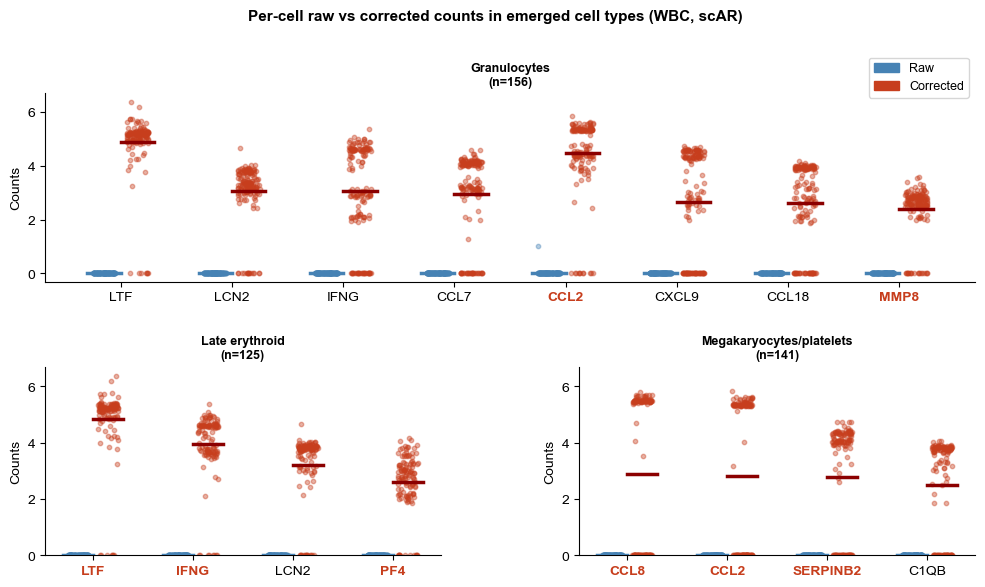

  Saved figure4_data/Fig_4_stripplot_wbc_scar.png
  wbc done

Processing pbmc...
  Loading scar...
    celltypist_cell_label_coarse: 1 emerged types
    celltypist_cell_label_fine: 0 emerged types


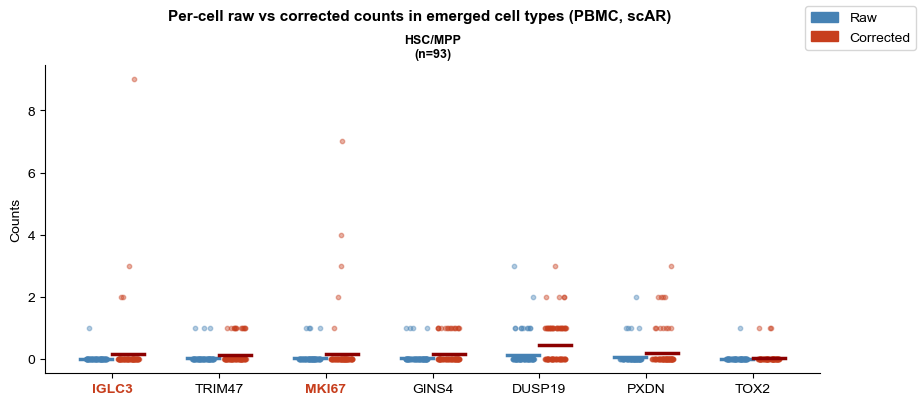

  Saved figure4_data/Fig_4_stripplot_pbmc_scar.png
  Loading cellclear...
    celltypist_cell_label_coarse: 0 emerged types
    celltypist_cell_label_fine: 0 emerged types
  pbmc done

Processing pfc...
  Loading scar...
    celltypist_cell_label: 8 emerged types


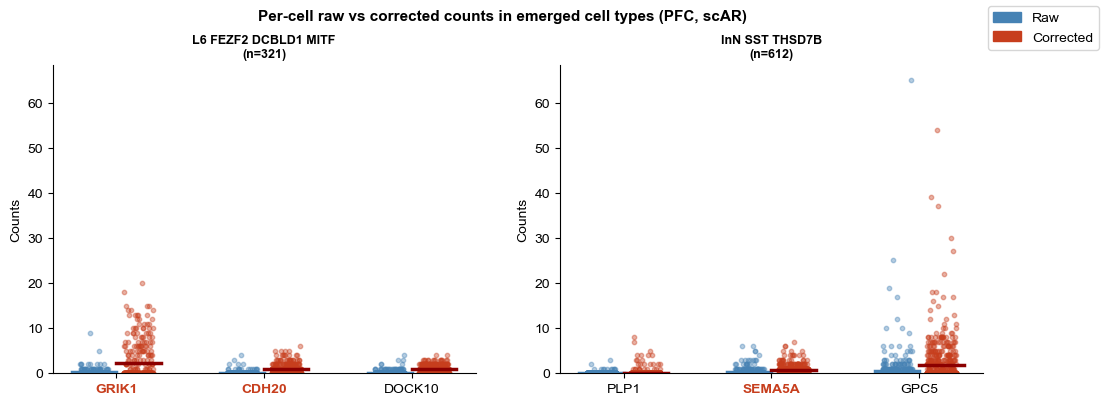

  Saved figure4_data/Fig_4_stripplot_pfc_scar.png
  Loading cellclear...
    celltypist_cell_label: 2 emerged types


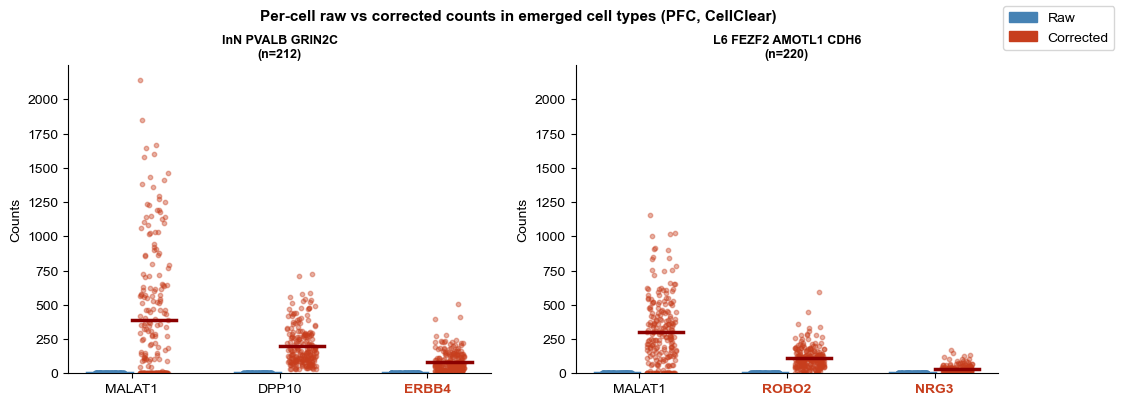

  Saved figure4_data/Fig_4_stripplot_pfc_cellclear.png
  pfc done

Emerged cell types summary:
dataset      tool                    label_col                cell_type  n_cells  top_z2p_gene  top_z2p_pct  top_z2p_mean_corr
    wbc      scar celltypist_cell_label_coarse                 Early MK       41           LTF        100.0           5.192000
    wbc      scar celltypist_cell_label_coarse             Granulocytes      156           LTF         95.5           4.880000
    wbc      scar celltypist_cell_label_coarse Megakaryocytes/platelets       69         RPS26         60.9           2.376000
    wbc      scar   celltypist_cell_label_fine           Late erythroid      125           LTF         94.4           4.824000
    wbc      scar   celltypist_cell_label_fine Megakaryocytes/platelets      141          C1QB         69.5           2.505000
   pbmc      scar celltypist_cell_label_coarse                  HSC/MPP       93     LINC01876         58.1           1.194000
    pfc      sca

In [4]:
legend_handles = [mpatches.Patch(color='steelblue', label='Raw'),
                  mpatches.Patch(color='#C73E1D',   label='Corrected')]
all_emerged = []

for dataset_name, config in BIO_FILES.items():
    print(f"\nProcessing {dataset_name}...")
    uncorrected = sc.read_h5ad(config['uncorrected'])

    for tool_key, path in [('scar', config['scar']), ('cellclear', config['cellclear'])]:
        if path is None: continue
        print(f"  Loading {tool_key}...")
        tool_adata = sc.read_h5ad(path)

        # ── Emerged cell type summary ──────────────────────────────────────
        for label_col in config['label_cols']:
            rows = summarize_emerged(uncorrected, tool_adata, label_col, tool_key, dataset_name)
            all_emerged.extend(rows)
            print(f"    {label_col}: {len(rows)} emerged types")

        # ── Stripplots ─────────────────────────────────────────────────────
        sp_cfg = STRIPPLOT_CONFIG.get(dataset_name, {}).get(tool_key)
        if sp_cfg is None:
            del tool_adata; continue

        panels  = sp_cfg['panels']
        layout  = sp_cfg['layout']

        if layout == 'single':
            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            p = panels[0]
            stripplot_row(ax, tool_adata, p['ct'], p['label_col'], p['genes'], p['canonical'])
            fig.legend(handles=legend_handles, fontsize=10, loc='upper right')

        elif layout == '2x2':
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            for ax, p in zip(axes, panels):
                stripplot_row(ax, tool_adata, p['ct'], p['label_col'], p['genes'], p['canonical'])
            # harmonize y
            ymax = max(ax.get_ylim()[1] for ax in axes)
            for ax in axes: ax.set_ylim(0, ymax)
            fig.legend(handles=legend_handles, fontsize=10, loc='upper right')

        elif layout == 'gridspec':
            fig = plt.figure(figsize=(12, 6))
            gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)
            ax_top   = fig.add_subplot(gs[0, :])
            ax_left  = fig.add_subplot(gs[1, 0])
            ax_right = fig.add_subplot(gs[1, 1])
            p0, p1, p2 = panels
            stripplot_row(ax_top,   tool_adata, p0['ct'], p0['label_col'], p0['genes'], p0['canonical'])
            stripplot_row(ax_left,  tool_adata, p1['ct'], p1['label_col'], p1['genes'], p1['canonical'])
            stripplot_row(ax_right, tool_adata, p2['ct'], p2['label_col'], p2['genes'], p2['canonical'])
            ymax = max(ax_left.get_ylim()[1], ax_right.get_ylim()[1])
            ax_left.set_ylim(0, ymax); ax_right.set_ylim(0, ymax)
            fig.legend(handles=legend_handles, loc='upper right',
                       bbox_to_anchor=(0.9, 0.95), fontsize=9)

        tool_label = 'scAR' if tool_key == 'scar' else 'CellClear'
        fig.suptitle(f'Per-cell raw vs corrected counts in emerged cell types '
                     f'({dataset_name.upper()}, {tool_label})',
                     fontweight='bold', fontsize=11, y=1.02)
        savepath = f'figure4_data/Fig_4_stripplot_{dataset_name}_{tool_key}.png'
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  Saved {savepath}")

        del tool_adata

    del uncorrected
    print(f"  {dataset_name} done")

# ── Summary table ──────────────────────────────────────────────────────────────
df_emerged = pd.DataFrame(all_emerged)
df_emerged.to_csv('figure4_data/emerged_celltypes_summary.csv', index=False)
print("\nEmerged cell types summary:")
print(df_emerged.to_string(index=False))

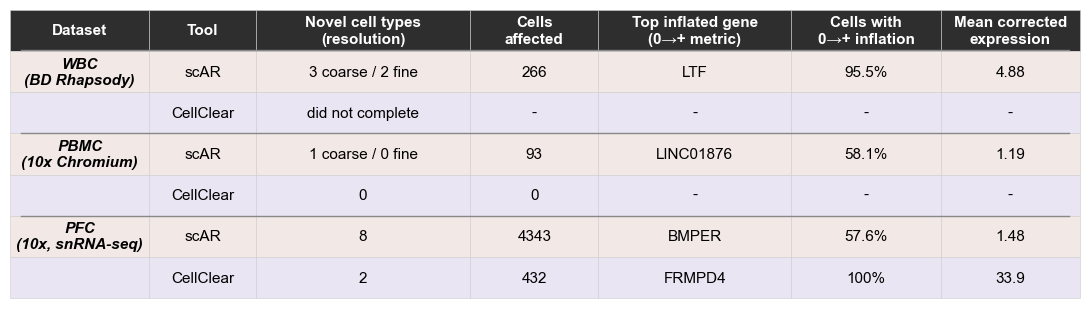

In [5]:
# Hardcoded from emerged cell type analysis output

table_data = [
    ['WBC\n(BD Rhapsody)',    'scAR',      '3 coarse / 2 fine',   266,  'LTF',        '95.5%', '4.88'],
    ['WBC\n(BD Rhapsody)',    'CellClear', 'did not complete',     '-',  '-',          '-',     '-'],
    ['PBMC\n(10x Chromium)',  'scAR',      '1 coarse / 0 fine',    93,  'LINC01876',  '58.1%', '1.19'],
    ['PBMC\n(10x Chromium)',  'CellClear', '0',                     0,   '-',          '-',     '-'],
    ['PFC\n(10x, snRNA-seq)', 'scAR',      '8',                  4343,  'BMPER',      '57.6%', '1.48'],
    ['PFC\n(10x, snRNA-seq)', 'CellClear', '2',                   432,  'FRMPD4',     '100%',  '33.9'],
]
col_labels  = ['Dataset', 'Tool', 'Novel cell types\n(resolution)',
               'Cells\naffected', 'Top inflated gene\n(0→+ metric)',
               'Cells with\n0→+ inflation', 'Mean corrected\nexpression']
col_widths  = [0.13, 0.10, 0.20, 0.12, 0.18, 0.14, 0.13]

display_data = [row[:] for row in table_data]
for i in [1, 3, 5]: display_data[i][0] = ''  # suppress repeated dataset labels

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
table = ax.table(cellText=display_data, colLabels=col_labels,
                 cellLoc='center', loc='center', colWidths=col_widths)
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1, 2.1)

for j in range(len(col_labels)):
    table[0,j].set_facecolor('#2E2E2E')
    table[0,j].set_text_props(color='white', fontweight='bold', fontsize=11)

for i, row in enumerate(table_data):
    color = '#F2E8E5' if row[1]=='scAR' else '#EAE5F2'
    for j in range(len(col_labels)):
        table[i+1,j].set_facecolor(color)
        if j==0 and i in [0,2,4]:
            table[i+1,j].set_text_props(fontsize=11, fontweight='bold', style='italic')

for (r,c), cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC'); cell.set_linewidth(0.4)

def row_y(row_idx, total_rows=7): return 1.0 - row_idx/total_rows
for ri in [1, 3, 5]:
    ax.plot([0.01,0.99], [row_y(ri)]*2, color='#888888', lw=1.0,
            transform=ax.transAxes, clip_on=False)

plt.tight_layout()
plt.savefig('figure4_data/Fig_4_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()